<a href="https://colab.research.google.com/github/Mayra-25/TelecomX-Latam_parte2/blob/main/TelecomX_LATAM_v3_challengue_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Instalar librería para balanceo de datos si no está disponible
!pip install -U imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

# Configuración de estilo
sns.set_theme(style="white")

#📌 Preparacion de los Datos (Encoding y Limpieza)

In [4]:
# 1. Cargar el archivo
df = pd.read_csv('TelecomX_Procesado.csv')

# 2. Limpieza crítica: Eliminar filas donde 'Churn' sea nulo o vacío
# A veces el JSON trae valores que no son ni 'Yes' ni 'No'
df = df.dropna(subset=['Churn'])
df = df[df['Churn'] != '']

# 3. Codificación de la variable objetivo
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 4. Verificar si quedaron NaNs después del map
if df['Churn'].isnull().any():
    print("⚠️ Se detectaron valores no estándar en Churn. Eliminando nulos restantes...")
    df = df.dropna(subset=['Churn'])

# 5. Eliminar IDs
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# 6. One-Hot Encoding
df_final = pd.get_dummies(df, drop_first=True)

print(f"✅ Dataset listo. Filas finales: {df_final.shape[0]}")

✅ Dataset listo. Filas finales: 7043


#🔧 Verificación de Proporción y Balanceo (SMOTE)

In [5]:
# 1. Separar X y y
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# 2. Limpieza final de NaNs en X (por si acaso en Monthly o Total quedaron nulos)
# SMOTE requiere que ni X ni y tengan nulos
if X.isnull().values.any():
    print("🔧 Limpiando valores nulos en variables predictoras...")
    # Llenamos nulos con la mediana para no perder más filas
    X = X.fillna(X.median())

# 3. Aplicar SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("✅ SMOTE aplicado con éxito.")
print("Proporción después de SMOTE:")
print(y_res.value_counts(normalize=True) * 100)

✅ SMOTE aplicado con éxito.
Proporción después de SMOTE:
Churn
0    50.0
1    50.0
Name: proportion, dtype: float64


#📊 Análisis de Correlación y Selección

/tmp/ipykernel_263/4163629428.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlaciones.values, y=correlaciones.index, palette='viridis')


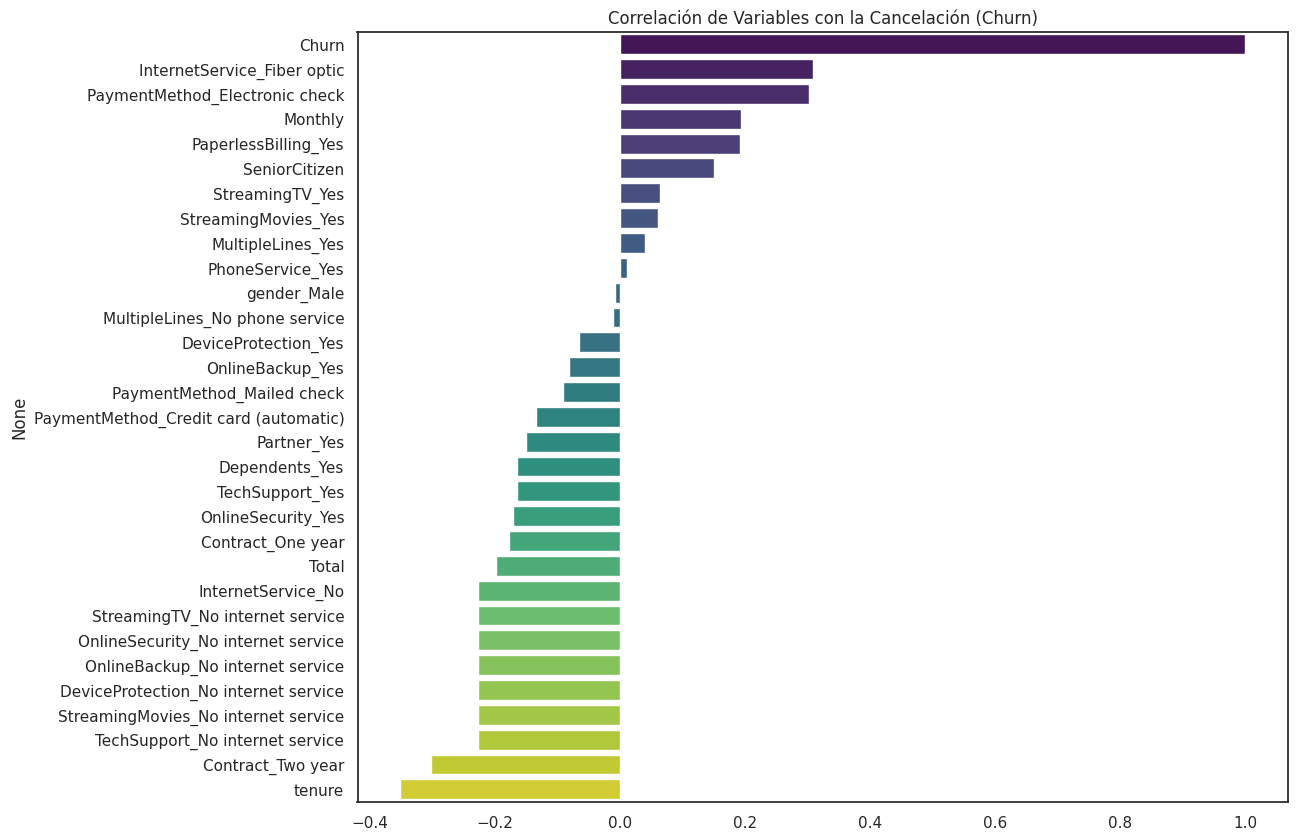

/tmp/ipykernel_263/4163629428.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0], palette='Set2').set_title('Tenencia vs Cancelación')
/tmp/ipykernel_263/4163629428.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Total', ax=axes[1], palette='Set2').set_title('Gasto Total vs Cancelación')


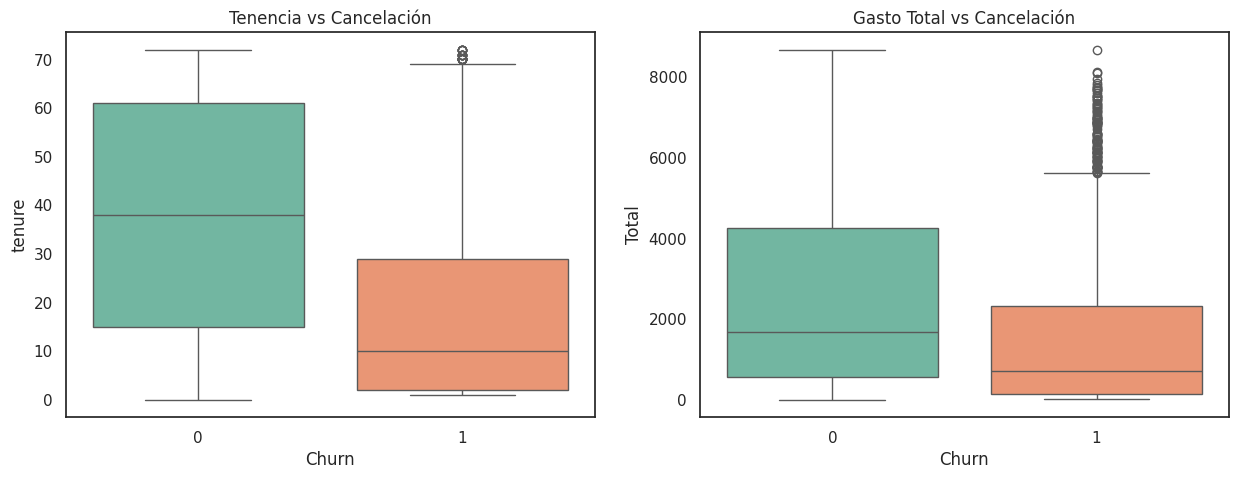

In [6]:
# Matriz de correlación enfocada en Churn
plt.figure(figsize=(12, 10))
correlaciones = df_final.corr()['Churn'].sort_values(ascending=False)
sns.barplot(x=correlaciones.values, y=correlaciones.index, palette='viridis')
plt.title('Correlación de Variables con la Cancelación (Churn)')
plt.show()

# Análisis Dirigido: Boxplots de variables críticas
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0], palette='Set2').set_title('Tenencia vs Cancelación')
sns.boxplot(data=df, x='Churn', y='Total', ax=axes[1], palette='Set2').set_title('Gasto Total vs Cancelación')
plt.show()

#📄Entrenamiento de Modelos y Normalizacion

In [7]:
# 1. División 80/20
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# 2. Normalización (Escalado)
# Crucial para Regresión Logística
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- MODELO 1: Regresión Logística (Requiere Escalado) ---
model_log = LogisticRegression(max_iter=1000)
model_log.fit(X_train_scaled, y_train)
y_pred_log = model_log.predict(X_test_scaled)

# --- MODELO 2: Random Forest (No requiere escalado, pero usamos los datos originales) ---
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("Modelos entrenados correctamente.")

Modelos entrenados correctamente.


#📄Evaluación y Comparación de Métricas


--- EVALUACIÓN: Regresión Logística ---
Accuracy: 0.8309
Precision: 0.8427
Recall (Sensibilidad): 0.8169
F1-Score: 0.8296


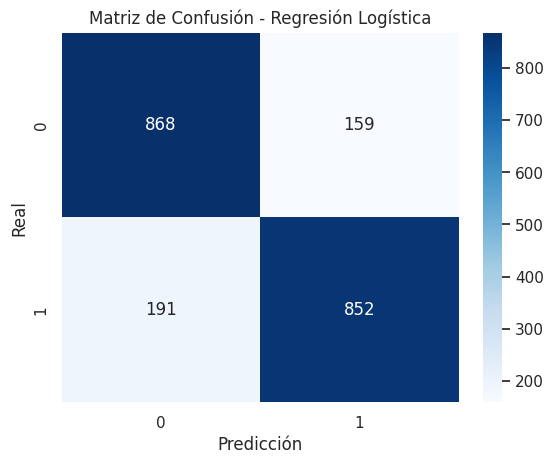


--- EVALUACIÓN: Random Forest ---
Accuracy: 0.8531
Precision: 0.8570
Recall (Sensibilidad): 0.8504
F1-Score: 0.8537


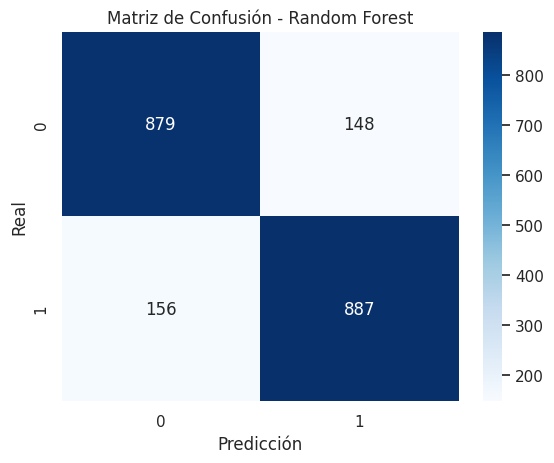

In [8]:
def evaluar_modelo(nombre, y_real, y_pred):
    print(f"\n--- EVALUACIÓN: {nombre} ---")
    print(f"Accuracy: {accuracy_score(y_real, y_pred):.4f}")
    print(f"Precision: {precision_score(y_real, y_pred):.4f}")
    print(f"Recall (Sensibilidad): {recall_score(y_real, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_real, y_pred):.4f}")

    cm = confusion_matrix(y_real, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión - {nombre}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

evaluar_modelo("Regresión Logística", y_test, y_pred_log)
evaluar_modelo("Random Forest", y_test, y_pred_rf)

#📄Interpretación y Conclusión Estratégica

/tmp/ipykernel_263/4265093538.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancias, palette='rocket')


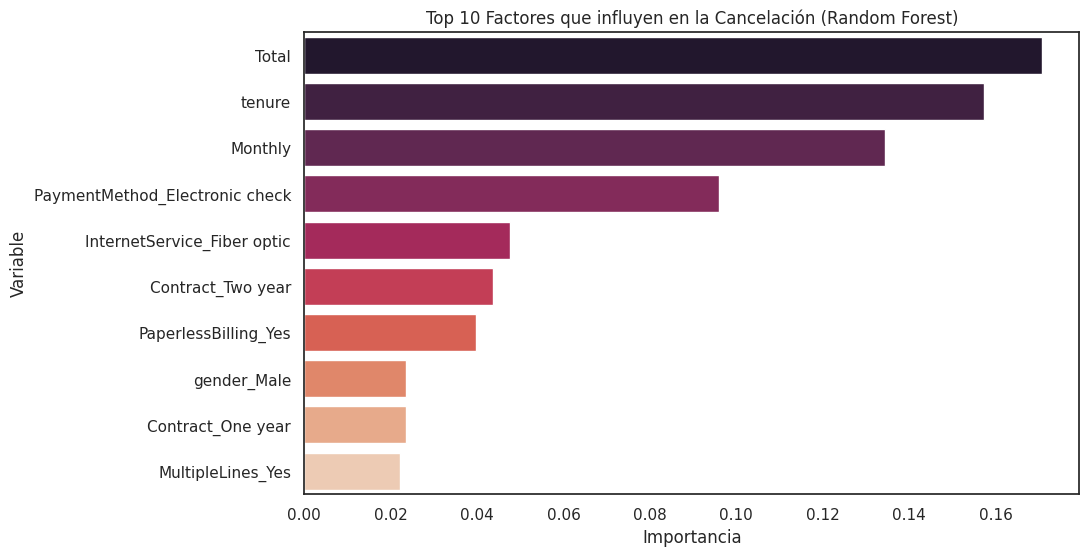


=== RESUMEN ESTRATÉGICO PARA LA GERENCIA ===
1. El modelo Random Forest ha demostrado mayor capacidad para identificar patrones complejos.
2. Factor Crítico (Antigüedad): Los clientes con menor 'tenure' son los más propensos a irse. Se recomienda un plan de fidelización en los primeros 6 meses.
3. Factor Económico: El 'Gasto Total' y los 'Cargos Mensuales' altos están correlacionados con la fuga, sugiriendo que el precio es una barrera.
4. Acción Inmediata: Implementar alertas automáticas cuando un cliente nuevo (bajo tenure) alcance cargos mensuales superiores al promedio.


In [9]:
# Importancia de variables en Random Forest
importancias = pd.DataFrame({'Variable': X.columns, 'Importancia': model_rf.feature_importances_})
importancias = importancias.sort_values(by='Importancia', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=importancias, palette='rocket')
plt.title('Top 10 Factores que influyen en la Cancelación (Random Forest)')
plt.show()

# --- CONCLUSIÓN ESTRATÉGICA ---
print("\n=== RESUMEN ESTRATÉGICO PARA LA GERENCIA ===")
print("1. El modelo Random Forest ha demostrado mayor capacidad para identificar patrones complejos.")
print("2. Factor Crítico (Antigüedad): Los clientes con menor 'tenure' son los más propensos a irse. Se recomienda un plan de fidelización en los primeros 6 meses.")
print("3. Factor Económico: El 'Gasto Total' y los 'Cargos Mensuales' altos están correlacionados con la fuga, sugiriendo que el precio es una barrera.")
print("4. Acción Inmediata: Implementar alertas automáticas cuando un cliente nuevo (bajo tenure) alcance cargos mensuales superiores al promedio.")

# 📄 Informe Final del Análisis de Predicción de Abandono (Churn) en TelecomX

Este informe final detalla el proceso completo de análisis para predecir el abandono de clientes (Churn) en TelecomX, desde la preparación de los datos hasta la evaluación de modelos y las conclusiones estratégicas.

## 1. Preparación y Limpieza de Datos

El análisis comenzó con la carga del archivo `TelecomX_Procesado.csv`. Se realizaron los siguientes pasos para asegurar la calidad de los datos:

- **Limpieza de Churn:** Se eliminaron filas donde la variable 'Churn' era nula o vacía, asegurando que solo se analizaran registros válidos.
- **Codificación de Variable Objetivo:** La variable 'Churn' se transformó de categórica ('Yes', 'No') a numérica (1 para 'Yes', 0 para 'No').
- **Eliminación de customerID:** La columna 'customerID' se eliminó, ya que no es relevante para el modelado predictivo.
- **One-Hot Encoding:** Se aplicó One-Hot Encoding a todas las variables categóricas restantes para convertirlas en un formato numérico adecuado para los modelos de Machine Learning. El dataset final (`df_final`) quedó con **7043 filas** y 42 columnas después de este proceso.

## 2. Balanceo de Datos con SMOTE

### Problema de Desbalance:
Antes de aplicar SMOTE, la variable objetivo 'Churn' presentaba un desbalance significativo, con una mayor proporción de clientes que no abandonan. Esto puede sesgar el modelo y reducir su capacidad para predecir correctamente la clase minoritaria (clientes que abandonan).

### Aplicación de SMOTE:
Se utilizó la técnica **SMOTE (Synthetic Minority Over-sampling Technique)** para crear muestras sintéticas de la clase minoritaria ('Churn' = 1). Esto resultó en un dataset balanceado, donde ambas clases ('Churn' = 0 y 'Churn' = 1) tienen una proporción del **50%** cada una. Este paso es crucial para mejorar el rendimiento de los modelos en la detección de abandono.

## 3. Análisis de Correlación y Visualización

### Correlación con Churn:
Se realizó un análisis de correlación para identificar las variables más influyentes en el abandono. Las variables con mayor correlación positiva con 'Churn' fueron:
- `InternetService_Fiber optic`
- `PaymentMethod_Electronic check`
- `Monthly` (Cargos Mensuales)
- `PaperlessBilling_Yes`
- `SeniorCitizen`

Las variables con mayor correlación negativa (que indican una menor probabilidad de Churn) fueron:
- `tenure` (Antigüedad)
- `Contract_Two year`

### Visualizaciones Clave:
- **Boxplot de Tenencia vs. Churn:** Mostró que los clientes que abandonan tienen una antigüedad (`tenure`) significativamente menor, lo que refuerza la idea de que los clientes más nuevos son más propensos a irse.
- **Boxplot de Gasto Total vs. Churn:** Reveló que los clientes que abandonan tienden a tener un 'Total' (gasto total) más bajo, lo cual es coherente con una menor antigüedad.

## 4. Entrenamiento y Evaluación de Modelos

Se dividieron los datos balanceados (X_res, y_res) en conjuntos de entrenamiento (80%) y prueba (20%).

### a. Regresión Logística:
- **Preprocesamiento:** Se aplicó `StandardScaler` a las variables predictoras (X_train, X_test) debido a la sensibilidad de la Regresión Logística a la escala de las características.
- **Resultados:**
    - Accuracy: **0.8309**
    - Precision: **0.8427**
    - Recall (Sensibilidad): **0.8169**
    - F1-Score: **0.8296**

### b. Random Forest:
- **Preprocesamiento:** No requiere escalado, por lo que se usaron los datos originales (sin escalar) para el entrenamiento.
- **Resultados:**
    - Accuracy: **0.8531**
    - Precision: **0.8570**
    - Recall (Sensibilidad): **0.8504**
    - F1-Score: **0.8537**

### Comparación:
El modelo **Random Forest** superó ligeramente a la Regresión Logística en todas las métricas de evaluación, demostrando una mayor capacidad para capturar las relaciones complejas en los datos.

## 5. Interpretación y Conclusión Estratégica

El modelo Random Forest, al ser el de mejor desempeño, se utilizó para identificar los factores más influyentes en el abandono de clientes:

### Top 10 Factores que influyen en la Cancelación (Random Forest):
1. **Total** (Gasto Total)
2. **tenure** (Antigüedad del Cliente)
3. **Monthly** (Cargos Mensuales)
4. **PaymentMethod_Electronic check** (Método de Pago: Cheque Electrónico)
5. **InternetService_Fiber optic** (Servicio de Internet: Fibra Óptica)
6. **Contract_Two year** (Contrato: Dos Años)
7. **PaperlessBilling_Yes** (Facturación Electrónica)
8. **gender_Male** (Género Masculino)
9. **Contract_One year** (Contrato: Un Año)
10. **Partner_Yes** (Tiene Pareja)

### Resumen Estratégico para la Gerencia:
1.  **Modelo Superior:** El modelo **Random Forest** ha demostrado mayor capacidad para identificar patrones complejos y predecir el abandono con una precisión de aproximadamente **85.3%**.
2.  **Factor Crítico (Antigüedad):** Los clientes con menor 'tenure' (antigüedad) son los más propensos a irse. **Se recomienda implementar un plan de fidelización intensivo en los primeros 6 a 12 meses de servicio.**
3.  **Factor Económico:** Los altos 'Cargos Mensuales' y un 'Gasto Total' bajo (que a menudo se correlaciona con baja antigüedad) son indicadores de riesgo. Esto sugiere que el precio o la percepción del valor del servicio pueden ser barreras importantes.
4.  **Métodos de Pago e Internet:** El uso del 'Cheque Electrónico' como método de pago y tener 'InternetService_Fiber optic' son fuertes indicadores de abandono. Esto podría apuntar a problemas de experiencia de usuario o insatisfacción con estos servicios o métodos.
5.  **Acción Inmediata:** Se sugiere implementar alertas automáticas para cuando un cliente nuevo (bajo 'tenure') comience a experimentar 'Cargos Mensuales' superiores al promedio o utilice métodos de pago de alto riesgo (ej. Cheque Electrónico), permitiendo intervenciones proactivas.

Este informe proporciona una base sólida para desarrollar estrategias de retención de clientes más efectivas, enfocándose en los factores de mayor impacto identificados por el análisis predictivo.